In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import joblib

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!ls /content/drive/MyDrive/autosort-ai

agent.ipynb					       db.ipynb
analysis.ipynb					       intent_classifier.pkl
Bitext_Sample_Customer_Service_Testing_Dataset.csv     main.ipynb
Bitext_Sample_Customer_Service_Training_Dataset.csv    README.md
Bitext_Sample_Customer_Service_Validation_Dataset.csv  requirements.gdoc
classifier.ipynb


In [15]:
def load_data():
    train = pd.read_csv("/content/drive/MyDrive/autosort-ai/Bitext_Sample_Customer_Service_Training_Dataset.csv")
    valid = pd.read_csv("/content/drive/MyDrive/autosort-ai/Bitext_Sample_Customer_Service_Validation_Dataset.csv")
    test = pd.read_csv("/content/drive/MyDrive/autosort-ai/Bitext_Sample_Customer_Service_Testing_Dataset.csv")
    return train, valid, test

In [17]:
def train_model(train_data, valid_data, label_encoder):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=5000)),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    pipeline.fit(train_data["utterance"], train_data["encoded_intent"])

    val_preds = pipeline.predict(valid_data["utterance"])
    decoded_preds = label_encoder.inverse_transform(val_preds)

    print("\n Validation Results:")
    print(classification_report(valid_data["intent"], decoded_preds))

    return pipeline

In [18]:
# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [19]:
# Plot per-class F1 scores
def plot_f1_scores(y_true, y_pred, labels, title="F1 Score per Intent"):
    f1_scores = f1_score(y_true, y_pred, labels=labels, average=None)
    plt.figure(figsize=(14, 6))
    sns.barplot(x=labels, y=f1_scores)
    plt.xticks(rotation=90)
    plt.title(title)
    plt.ylabel("F1 Score")
    plt.ylim(0.8, 1.05)
    plt.tight_layout()
    plt.show()

In [20]:
# Plot accuracy as gauge
def plot_accuracy_gauge(accuracy):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh([0], [accuracy], height=0.5, color='green')
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_title(f"Overall Accuracy: {accuracy*100:.2f}%", fontsize=14)
    plt.show()

In [21]:
def evaluate_model(model, test_data, label_encoder):
    y_true = test_data["intent"]
    y_encoded = label_encoder.transform(y_true)
    y_pred = model.predict(test_data["utterance"])
    y_pred_decoded = label_encoder.inverse_transform(y_pred)
    labels = sorted(test_data["intent"].unique())

    print("\n🧪 Test Results:")
    print(classification_report(y_true, y_pred_decoded))
    print("Test Accuracy:", accuracy_score(y_true, y_pred_decoded))

    results_df = test_data.copy()
    results_df["predicted_intent"] = y_pred_decoded
    results_df.to_csv("/content/drive/MyDrive/autosort-ai/predictions.csv", index=False)
    print("✅ Predictions saved to predictions.csv")

    plot_confusion_matrix(y_true, y_pred_decoded, labels)
    plot_f1_scores(y_true, y_pred_decoded, labels)
    plot_accuracy_gauge(accuracy_score(y_true, y_pred_decoded))

In [22]:
def save_model(model, label_encoder, path="/content/drive/MyDrive/autosort-ai/intent_classifier.pkl"):
    joblib.dump({
        "pipeline": model,
        "label_encoder": label_encoder
    }, path)
    print(f"✅ Model saved to {path}")


 Validation Results:
                          precision    recall  f1-score   support

            cancel_order       0.97      1.00      0.99        34
            change_order       1.00      1.00      1.00        33
 change_shipping_address       1.00      1.00      1.00        28
  check_cancellation_fee       1.00      1.00      1.00        26
           check_invoice       1.00      1.00      1.00        35
   check_payment_methods       1.00      1.00      1.00        25
     check_refund_policy       0.96      1.00      0.98        25
               complaint       1.00      1.00      1.00        23
contact_customer_service       1.00      1.00      1.00        22
     contact_human_agent       1.00      1.00      1.00        30
          create_account       1.00      0.97      0.99        36
          delete_account       1.00      0.97      0.98        33
        delivery_options       1.00      1.00      1.00        34
         delivery_period       1.00      1.00      1.

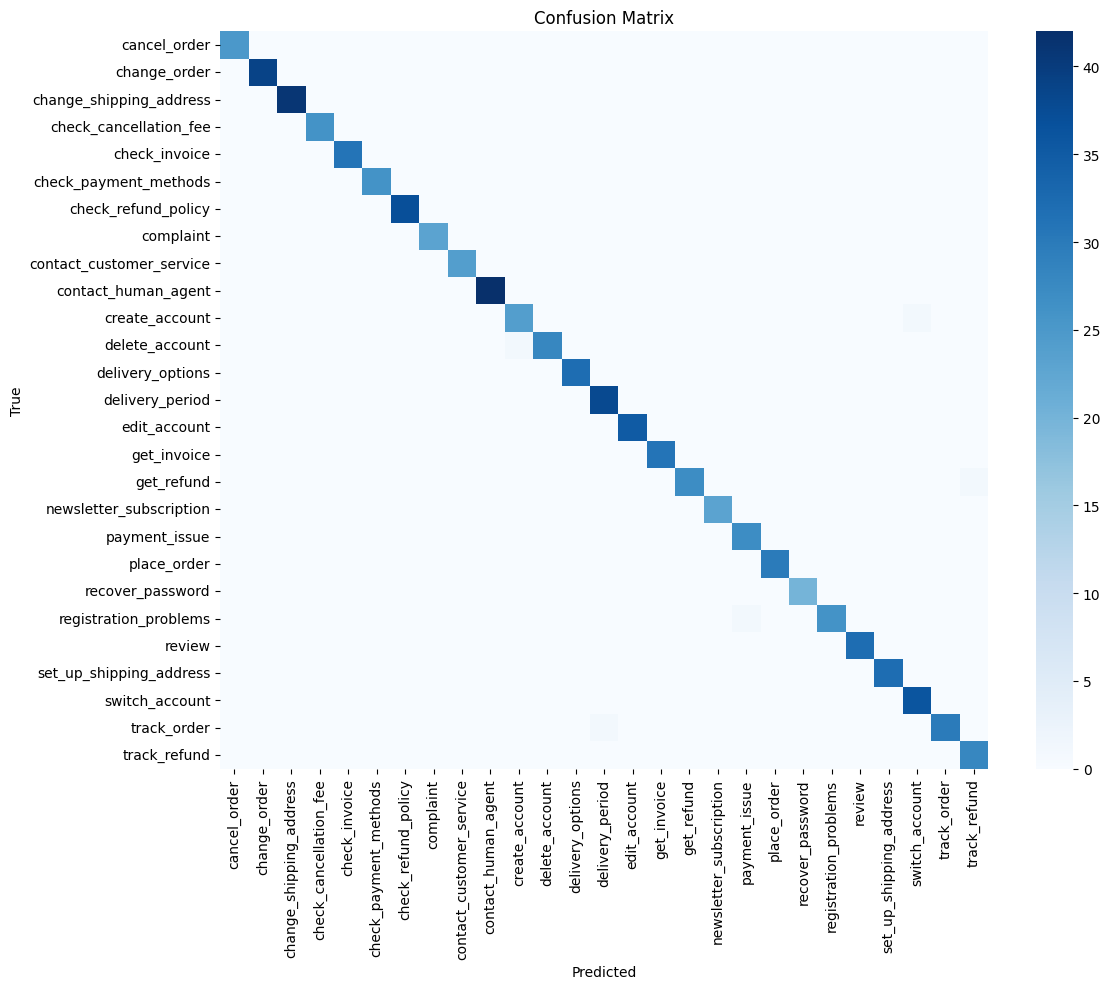

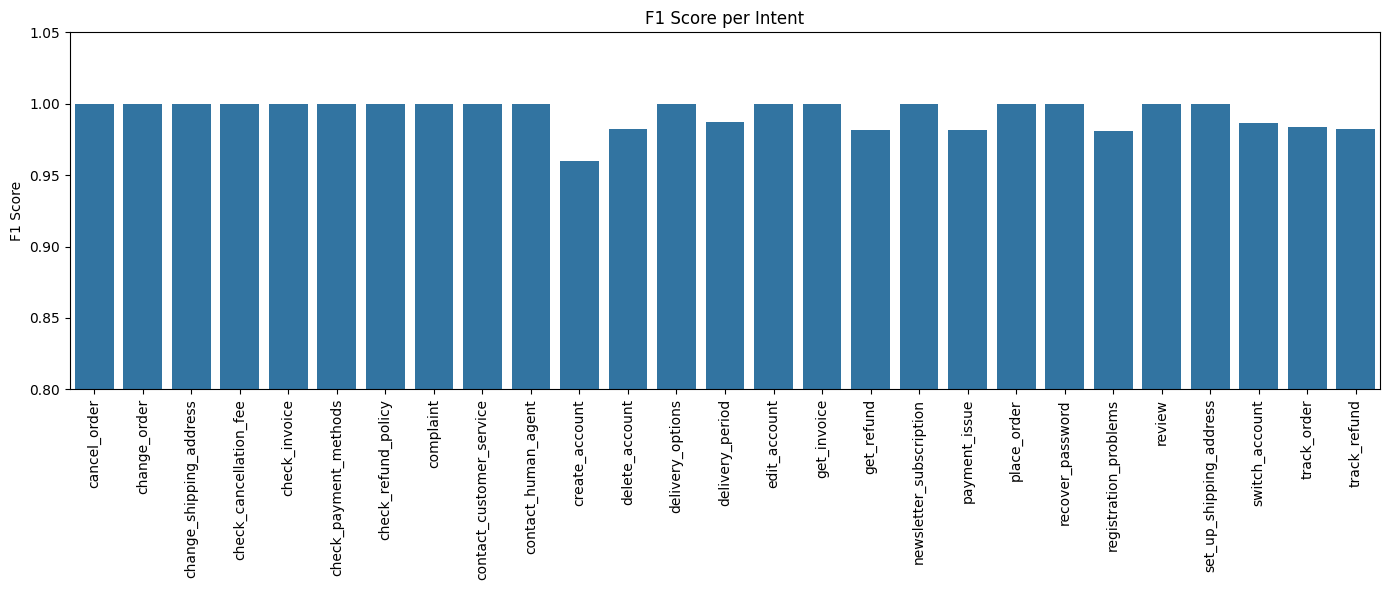

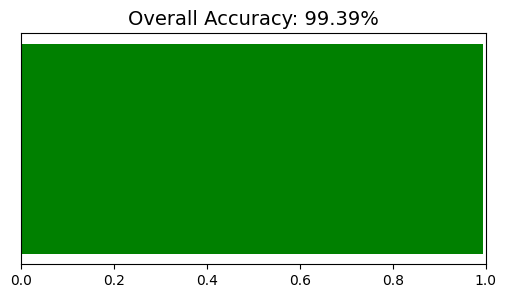

✅ Model saved to /content/drive/MyDrive/autosort-ai/intent_classifier.pkl


In [23]:
if __name__ == "__main__":
    train, valid, test = load_data()
    label_encoder = LabelEncoder()

    train["encoded_intent"] = label_encoder.fit_transform(train["intent"])
    valid["encoded_intent"] = label_encoder.transform(valid["intent"])

    model = train_model(train, valid, label_encoder)
    evaluate_model(model, test, label_encoder)
    save_model(model, label_encoder)

In [24]:
model_bundle = joblib.load("/content/drive/MyDrive/autosort-ai/intent_classifier.pkl")
model = model_bundle["pipeline"]
label_encoder = model_bundle["label_encoder"]

def predict_intent(text):
    pred = model.predict([text])
    return label_encoder.inverse_transform(pred)[0]